In [9]:
#############################################
"""
1. This file Generate the Dataset for training
"""

'\n1. This file Generate the Dataset for training\n'

In [10]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.LoRa import LoRa

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

In [11]:
fs = 1000000   # 1 MHz
bw = 125e3          # LoRa Bandwidth (125 kHz)
sf = 9       # Spreading Factor 

symbol_time = 2**sf / bw  # Symbol duration
N = 2**sf

lora_init = LoRa(sf, bw)

In [12]:
# GENERATE NEW DATASET (ONCE)
GEENRATE_ = True
SNR_first = 30
SNR_last = 29

if (GEENRATE_):

    folder_path = "dataset_sf9_512x33"

    # Check if folder exists, if not create it
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder created: {folder_path}")
    else:
        print(f"Folder already exists: {folder_path}")
    # Outer loop: from 15 to -30 (inclusive)
    for i in range(SNR_first, SNR_last, -1):  # step -1 to count down
        # Inner loop: 100 iterations
        for j in range(512): # 0 until 511
            x1 = lora_init.gen_symbol_fs(j, sf=sf, bw=bw, Fs=fs)  # you had Fs=int(bw*8)=1e6
            snr = i
            x = lora_init.awgn_iq(x1,snr)
            #### DOWNSAMPLING
            create_spectrogram_from_torch(x,sf,bw,fs,256,17,i,j,1,folder_path)
       

Folder already exists: dataset_sf9_512x33


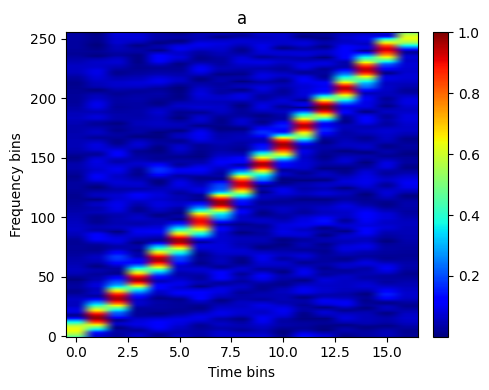

(256, 17)
float64
0.10586173475298118
0.00047116561127577946
1.0


In [13]:
file_path = "dataset_sf9_256x17_more/s_sf9_bw125_2_0_1.npy"  # example path
data2 = np.load(file_path)

show_multiple_spectrograms([data2],["a"],1)
print(data2.shape)
print(data2.dtype)
print(data2.mean())
print(data2.min())
print(data2.max())